# Econ 771 - Problem Set 1


In [2]:
# Import necessary packages
import pandas as pd

## Exercise IV

**1. This problem requires the dataset 'ps1.csv' posted on Canvas. Consider the model**

**$$Y = X^T\beta + \epsilon, \ \ \ \ \ \ E[\epsilon | X] = 0,$$
where the first element of $\beta$ is an intercept.**

In [3]:
# Load data from a CSV file on GitHub
ps1_data = pd.read_csv('https://raw.githubusercontent.com/JiaxiLi1995/Econ771_python/main/ps1.csv')

# Load first few lines to have a feeling of the data
print(ps1_data.head())

           Y        X1        X2
0 -13.444401 -3.932381  0.178857
1   9.073762  1.537573  2.045916
2  -2.340808 -0.058261  0.127293
3  14.271870  2.790517  0.214336
4   9.833066  2.150371  1.564950


**2. In a figure with 2 panels, plot $X_1$ vs $Y$ and $X_2$ vs $Y$.**

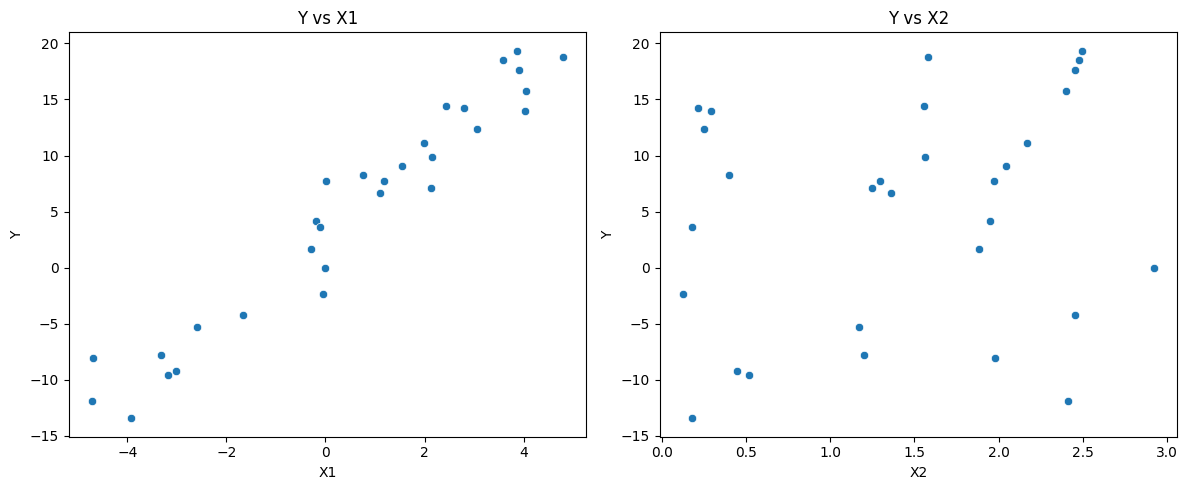

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot X1 vs Y in the first subplot
sns.scatterplot(data=ps1_data, x='X1', y='Y', ax=axes[0])
axes[0].set_title('Y vs X1')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('Y')

# Plot X2 vs Y in the second subplot
sns.scatterplot(data=ps1_data, x='X2', y='Y', ax=axes[1])
axes[1].set_title('Y vs X2')
axes[1].set_xlabel('X2')
axes[1].set_ylabel('Y')

# Display the plot
plt.tight_layout()
plt.show()

**3. Calculate the OLS estimates $\hat{\beta}$.**

In [8]:
import numpy as np

# Define the dependent variable Y
Y = ps1_data['Y'].values.reshape(-1, 1)

# Define the independent variables X1, X2, and add a constant (intercept) to X1 and X2
X_data = ps1_data[['X1', 'X2']].values
intercept = np.ones((X_data.shape[0], 1))
X = np.hstack((intercept, X_data))

# Calculate OLS estimates (beta_hat) : (X^T X)^-1 X^T Y
XtX = np.dot(X.T, X)
XtX_inv = np.linalg.inv(XtX)
XtY = np.dot(X.T, Y)

beta_hat = np.dot(XtX_inv, XtY)

# Print the OLS estimates
print("OLS Estimates (β̂):")
print(f"const: {beta_hat[0][0]:.6f}")
print(f"X1:    {beta_hat[1][0]:.6f}")
print(f"X2:    {beta_hat[2][0]:.6f}")


OLS Estimates (β̂):
const: 1.801366
X1:    3.410789
X2:    0.989512


**4. Calculate the $R^2$ (coefficient of determination).**

In [9]:
# Calculate fitted values (Ŷ)
Y_hat = np.dot(X, beta_hat)

# Calculate the mean of Y
Y_mean = np.mean(Y)

# Calculate Total Sum of Squares (SST)
SST = np.sum((Y - Y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((Y - Y_hat)**2)

# Calculate R-squared
R_squared = 1 - (SSR / SST)

# Print R-squared
print(f"R-squared: {R_squared:.6f}")

R-squared: 0.949491


**5. Calculate the fitted values $\hat{y}$ and overlay them on the plots in the first figure. Make the figure look nice.**

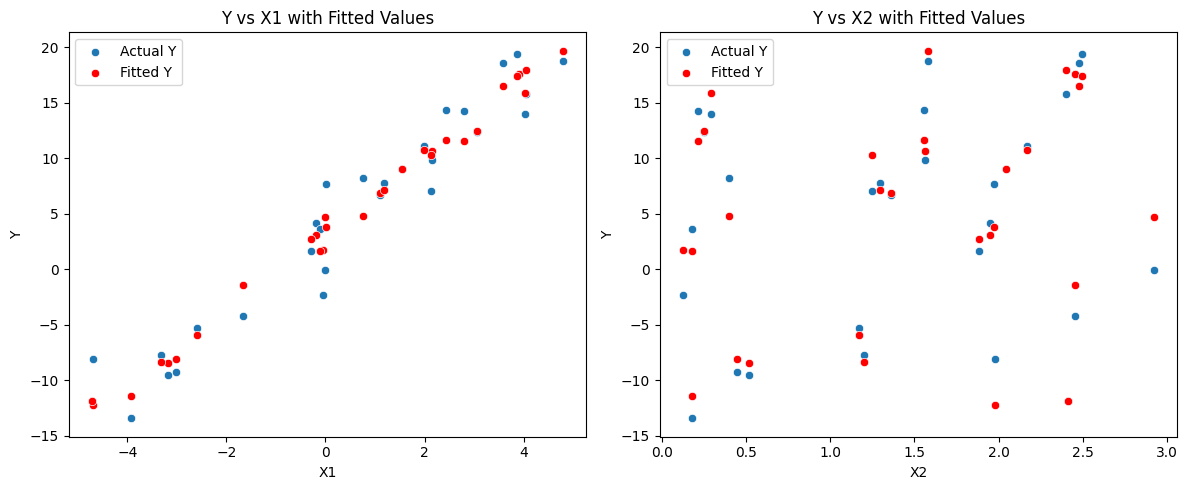

In [11]:
# Calculate fitted values (Ŷ)
Y_hat = np.dot(X, beta_hat)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot X1 vs Y and overlay fitted values
sns.scatterplot(data=ps1_data, x='X1', y='Y', ax=axes[0], label='Actual Y')
sns.scatterplot(x=ps1_data['X1'], y=Y_hat.flatten(), ax=axes[0], color='red', label='Fitted Y')
axes[0].set_title('Y vs X1 with Fitted Values')

axes[0].set_xlabel('X1')
axes[0].set_ylabel('Y')
axes[0].legend()

# Plot X2 vs Y and overlay fitted values
sns.scatterplot(data=ps1_data, x='X2', y='Y', ax=axes[1], label='Actual Y')
sns.scatterplot(x=ps1_data['X2'], y=Y_hat.flatten(), ax=axes[1], color='red', label='Fitted Y')
axes[1].set_title('Y vs X2 with Fitted Values')
axes[1].set_xlabel('X2')
axes[1].set_ylabel('Y')
axes[1].legend()

# Display the plot
plt.tight_layout()
plt.show()

**6. What conclusions can you draw from this information? Explain.**

The overall fit is very strong with a high $R^2$, indicating that most sample variations of the dependent variables can be explained by sample variations of the dependent variables in the model. From the scatterplot $Y$ versus $X_1$, the relationship looks strongly increasing and close to linear, and the estimated coefficient for $X_1$ is relatively large at around $3.41$. Note that high $R^2$ does not directly indicate that the model is correctly specified or that errors are well behaved, such as the constant variance, in spite that the residuals are small relative to total variation.
